# Oil & Gas Topside: Production & Energy Optimization

This notebook demonstrates NeqSim's **production optimization** and **energy optimization** functionality on the same oil/gas separation + recompression process used in the NeqSim-Colab `comparesimulations.ipynb` example.

The base process is built from the reference Java class `neqsim.process.examples.OilGasProcessSimulationOptimization` (HP/MP/LP three-stage separation, three-stage gas recompression, dew-point control, and two export compressors). A **final sales-gas export compressor train** is then added as a **separate process area**, so the overall simulation becomes a multi-area `ProcessModel`.

Four optimization studies are shown:

1. **Production (throughput) optimization** — maximise sales-gas production by varying well feed rate to the bottleneck (`ProductionOptimizer`).
2. **Energy optimization** — minimise total shaft power by optimising the inter-stage export pressure split (`ProductionOptimizer`, MINIMIZE objective).
3. **Full-plant throughput-to-bottleneck** — find the maximum feed multiplier the whole multi-area plant can sustain (`ProcessModelThroughputOptimizer`).
4. **Multi-objective Pareto** — production vs energy trade-off (`ProductionOptimizer.optimizePareto`).

> Units: temperature in Kelvin, pressure in bara (NeqSim Java API convention).

**Runtime:** Use Git and JDK 17 or newer. The setup uses compiled repository classes when present; otherwise it fetches and builds the corrected documentation source from `refs/pull/3597/head`. Set `NEQSIM_GIT_REF` to validate another fixed revision. The public Python package alone does not contain all Java fixes exercised here. Run all cells from a fresh kernel.


In [1]:
import importlib.util
import os
import subprocess
import sys
import tempfile
from pathlib import Path

# Install Python packages with this notebook kernel. Java runs from the
# validated documentation source below, ahead of the package's bundled JAR.
required = {"neqsim": "neqsim>=3.20.0,<4", "numpy": "numpy",
            "scipy": "scipy>=1.14,<2", "matplotlib": "matplotlib", "pandas": "pandas"}
missing = [package for module, package in required.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

candidate = Path(os.environ.get("NEQSIM_PROJECT_ROOT", Path.cwd())).resolve()
PROJECT_ROOT = next((p for p in [candidate, *candidate.parents]
                     if (p / "pom.xml").is_file()
                     and (p / "devtools/neqsim_dev_setup.py").is_file()), None)
if PROJECT_ROOT is None:
    # The public package alone predates fixes exercised by these examples.
    # Use the validated documentation PR's source; override with another fixed
    # commit or ref through NEQSIM_GIT_REF when validating a newer revision.
    source_ref = os.environ.get("NEQSIM_GIT_REF", "refs/pull/3597/head")
    PROJECT_ROOT = Path(tempfile.mkdtemp(prefix="neqsim-optimization-"))
    subprocess.check_call(["git", "init", "-q", str(PROJECT_ROOT)])
    subprocess.check_call(["git", "-C", str(PROJECT_ROOT), "remote", "add", "origin",
                           "https://github.com/equinor/neqsim.git"])
    subprocess.check_call(["git", "-C", str(PROJECT_ROOT), "fetch", "--depth", "1",
                           "origin", source_ref])
    subprocess.check_call(["git", "-C", str(PROJECT_ROOT), "checkout", "--quiet",
                           "--detach", "FETCH_HEAD"])
    print(f"Fetched NeqSim documentation source: {source_ref}")

if not (PROJECT_ROOT / "target/classes/neqsim/thermo/system/SystemSrkEos.class").is_file():
    # Requires Git and JDK 17+ before the first source build.
    # The Maven wrapper downloads its own Maven distribution and dependencies.
    wrapper = "mvnw.cmd" if os.name == "nt" else "mvnw"
    build = subprocess.run(
        [str(PROJECT_ROOT / wrapper), "-q", "-DskipTests", "compile",
         "dependency:build-classpath", "-DincludeScope=runtime",
         "-Dmdep.outputFile=target/neqsim-dev-classpath.txt",
         f"-Dmdep.pathSeparator={os.pathsep}"],
        cwd=PROJECT_ROOT, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    )
    if build.returncode:
        raise RuntimeError("NeqSim source build failed:\n" + build.stdout[-12000:])

os.environ["NEQSIM_PROJECT_ROOT"] = str(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT,
                              recompile=False, verbose=False))
NEQSIM_MODE = "workspace target/classes"
from neqsim import jneqsim
import numpy as np
import matplotlib.pyplot as plt

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

def save_figure(filename):
    plt.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

print(f"NeqSim source: {NEQSIM_MODE}")


All NeqSim classes imported OK
NeqSim source: workspace target/classes


In [2]:
# Imports for jpype functional interfaces and plotting
import jpype
from jpype import JImplements, JOverride
import numpy as np
import matplotlib.pyplot as plt

# Java optimizer classes
OilGasProcess = ns.JClass("neqsim.process.examples.OilGasProcessSimulationOptimization")
ProductionOptimizer = ns.JClass("neqsim.process.util.optimizer.ProductionOptimizer")
OptimizationConfig = ProductionOptimizer.OptimizationConfig
ManipulatedVariable = ProductionOptimizer.ManipulatedVariable
OptimizationObjective = ProductionOptimizer.OptimizationObjective
SearchMode = ProductionOptimizer.SearchMode
ObjectiveType = ProductionOptimizer.ObjectiveType
ProcessModel = ns.JClass("neqsim.process.processmodel.ProcessModel")
ProcessModelThroughputOptimizer = ns.JClass(
    "neqsim.process.util.optimizer.ProcessModelThroughputOptimizer"
)
Compressor = ns.JClass("neqsim.process.equipment.compressor.Compressor")
Cooler = ns.JClass("neqsim.process.equipment.heatexchanger.Cooler")
Arrays = jpype.JClass("java.util.Arrays")
print("Classes loaded.")


Classes loaded.


## 1. Build the base topside process (Area 1)

The reference Java class constructs the well fluid (PR-EOS, C7+ characterised) and the full separation + recompression flowsheet. We call `createProcess()` and apply the default operating setpoints with `updateInput(...)`. We do **not** run it yet — the export area is added first so both areas converge together inside the `ProcessModel`.

In [3]:
sim = OilGasProcess()
process = sim.createProcess()  # Area 1 ProcessSystem ('Topside process')
process.setName("Topside process")
sim.updateInput(sim.getInputParameters())  # apply default setpoints

compressor_names = ["23-KA-03", "23-KA-02", "23-KA-01", "27-KA-01"]
print("Base process units:", process.size())
print("Export gas stream present:", process.getUnit("export gas") is not None)


Base process units: 42
Export gas stream present: True


## 2. Add the sales-gas export compressor train (Area 2)

A separate `ProcessSystem` boosts the topside *export gas* (~189 bara) up to a **pipeline sales pressure of 230 bara** with an after-cooler to 30 degC. The Area-1 `export gas` stream object is shared **by reference** as the Area-2 feed — the canonical NeqSim cross-area coupling pattern. Both areas are then combined in a `ProcessModel` and solved together.

In [4]:
ProcessSystem = ns.JClass("neqsim.process.processmodel.ProcessSystem")

export_area = ProcessSystem()
export_area.setName("Export compression")

export_gas = process.getUnit("export gas")  # shared by reference from Area 1

sales_compressor = Compressor("30-KA-01", export_gas)
sales_compressor.setOutletPressure(230.0, "bara")
sales_compressor.setIsentropicEfficiency(0.78)

sales_cooler = Cooler("30-HA-01", sales_compressor.getOutletStream())
sales_cooler.setOutTemperature(273.15 + 30.0)
sales_cooler.getOutletStream().setName("sales gas export")

export_area.add(sales_compressor)
export_area.add(sales_cooler)
export_area.add(sales_cooler.getOutletStream())

plant = ProcessModel()
plant.add("Topside process", process)
plant.add("Export compression", export_area)


def run_plant():
    assert plant.runUntilConverged(50, 5.0e-3), "Full plant did not converge"


run_plant()
base_interstage_bara = float(process.getUnit("23-KA-01").getOutletStream().getPressure("bara"))
print("Multi-area ProcessModel converged.")

# --- Define an explicit installed-power capacity basis per compressor ------
# The reference flowsheet ships its compressors WITHOUT a performance chart.
# NeqSim now recognises this and automatically disables the chart-dependent
# capacity metrics (surge, stonewall, speed) for chartless machines, so the
# compressor utilization is driven by its shaft-power constraint and scales
# smoothly with feed rate. We only need to give each machine a realistic
# installed shaft power (130% of its base operating point = 23% design
# margin); utilization then equals power / installed_power and the optimizer
# gets a genuine feasible interior point instead of a degenerate 100% pin.
DESIGN_POWER_MARGIN = 1.30  # installed power = 1.30 x base operating power


def set_compressor_capacity(comp, margin=DESIGN_POWER_MARGIN):
    base_kw = float(comp.getPower("kW"))
    installed_kw = max(base_kw * margin, 100.0)
    comp.initMechanicalDesign()  # creates the CompressorMechanicalDesign
    comp.getMechanicalDesign().setMaxDesignPower(installed_kw)
    # No manual constraint disabling needed: chartless compressors keep their
    # surge/speed/stonewall constraints present-but-disabled automatically.
    return installed_kw


for _name in compressor_names:
    set_compressor_capacity(process.getUnit(_name))
set_compressor_capacity(export_area.getUnit("30-KA-01"))
run_plant()
print("Compressor capacity basis set (power-limited); plant re-solved.")


Multi-area ProcessModel converged.
Compressor capacity basis set (power-limited); plant re-solved.


In [5]:
# --- Helper functions -------------------------------------------------
def stream_flow(proc, name, unit="kg/hr"):
    return float(proc.getUnit(name).getFlowRate(unit))


def area1_compressor_power_kw(proc):
    total = 0.0
    for name in compressor_names:
        total += float(proc.getUnit(name).getPower("kW"))
    return total


def plant_total_power_kw():
    # Plant-wide aggregate over all ProcessModel areas (compressors + pumps).
    return float(plant.getPower("kW"))


base_feed_kgph = stream_flow(process, "well stream", "kg/hr")
base_sales_gas = stream_flow(export_area, "sales gas export", "kg/hr")
base_export_oil = stream_flow(process, "export oil", "kg/hr")
base_power = plant_total_power_kw()

print(f"Base feed rate      : {base_feed_kgph:10.1f} kg/hr")
print(f"Sales gas export    : {base_sales_gas:10.1f} kg/hr")
print(f"Export oil          : {base_export_oil:10.1f} kg/hr")
print(f"Total shaft power   : {base_power:10.1f} kW")
print(f'Plant cooler duty   : {plant.getCoolerDuty("MW"):10.3f} MW')
print(f'Plant heater duty   : {plant.getHeaterDuty("MW"):10.3f} MW')


Base feed rate      :   667592.2 kg/hr
Sales gas export    :   107626.8 kg/hr
Export oil          :   556996.9 kg/hr
Total shaft power   :    11129.6 kW
Plant cooler duty   :    -24.488 MW
Plant heater duty   :    -19.043 MW


## 3b. Capacity observation snapshot (closed-loop / ML observation vector)

Every `ProcessSystem` and `ProcessModel` exposes a **side-effect-free** utilization snapshot via `getUtilizationSnapshotJson()` (and `ProcessAutomation.getUtilizationSnapshot()`). It reports, for each unit, the maximum capacity utilization, the limiting constraint, a per-constraint breakdown, feasibility, and (for compressors/pumps) shaft power, plus a plant-wide `bottleneck` and `anyOverloaded` flag.

This is the canonical **observation vector** for closed-loop / reinforcement-learning optimization: pair it with `ProcessAutomation.evaluate(...)` (the action + reward step). The snapshot does **not** run the flowsheet — call `run_plant()` (or `evaluate`) first so it reflects the latest setpoints.

In [6]:
import json as _json

# The snapshot is read directly off the already-solved plant (no extra run()).
snapshot = _json.loads(str(plant.getUtilizationSnapshotJson()))

print(f"schemaVersion : {snapshot['schemaVersion']}")
print(f"anyOverloaded : {snapshot['anyOverloaded']}")
bn = snapshot.get("bottleneck")
if bn:
    print(
        f"bottleneck    : {bn['name']}  "
        f"({bn['utilizationPercent']:.1f} %  "
        f"on {bn.get('limitingConstraint', 'n/a')})"
    )

print("\nPer-compressor utilization (power-limited basis):")
for u in snapshot["units"]:
    if u["type"] == "Compressor":
        pw = u.get("power_kW")
        pw_s = f"{pw:8.1f} kW" if pw is not None else "      n/a"
        print(
            f"  {u['area']:>20s} / {u['name']:<10s} "
            f"util = {u['maxUtilizationPercent']:5.1f} %   power = {pw_s}   "
            f"limit = {u.get('limitingConstraint')}"
        )


schemaVersion : 1.0
anyOverloaded : False
bottleneck    : 23-KA-01  (76.9 %  on power)

Per-compressor utilization (power-limited basis):
       Topside process / 23-KA-03   util =  76.9 %   power =    310.6 kW   limit = power
       Topside process / 23-KA-02   util =  76.9 %   power =    749.9 kW   limit = power
       Topside process / 23-KA-01   util =  76.9 %   power =   5335.6 kW   limit = power
       Topside process / 27-KA-01   util =  76.9 %   power =   2947.4 kW   limit = power
    Export compression / 30-KA-01   util =  76.9 %   power =    698.1 kW   limit = power


## 3. Production (throughput) optimization

`ProductionOptimizer.optimize(plant, ...)` runs both process areas to convergence
and checks capacities across the complete `ProcessModel`. Its objective reads
the actual sales-gas stream in the export area. The specified compressor ratings
are synthetic: installed power is 1.30 times each base operating load. Vessel,
valve and other equipment limits require their own installed design data.

The bounded one-variable search varies well feed while keeping all operating
setpoints fixed. An explicit assertion prevents an infeasible candidate being
reported as a successful optimum.


In [7]:
@JImplements("java.util.function.BiConsumer")
class FeedRateSetter:
    @JOverride
    def accept(self, proc, value):
        proc.getUnit("Topside process::well stream").setFlowRate(float(value), "kg/hr")


@JImplements("java.util.function.ToDoubleFunction")
class SalesGasObjective:
    @JOverride
    def applyAsDouble(self, proc):
        return float(proc.getUnit("Export compression::sales gas export").getFlowRate("kg/hr"))


feed_var = ManipulatedVariable(
    "well feed", 0.5 * base_feed_kgph, 1.5 * base_feed_kgph, "kg/hr", FeedRateSetter()
)

prod_config = (
    OptimizationConfig(0.5 * base_feed_kgph, 1.5 * base_feed_kgph)
    .searchMode(SearchMode.GOLDEN_SECTION_SCORE)
    .maxIterations(20)
    .tolerance(100.0)
    .rejectInvalidSimulations(True)
)

prod_objectives = Arrays.asList(
    OptimizationObjective("production", SalesGasObjective(), 1.0, ObjectiveType.MAXIMIZE)
)

optimizer = ProductionOptimizer()
prod_result = optimizer.optimize(
    plant, Arrays.asList(feed_var), prod_config, prod_objectives, None
)

assert prod_result.isFeasible(), str(prod_result.getInfeasibilityDiagnosis())

prod_opt_feed = float(prod_result.getDecisionVariables().get("well feed"))
print(f"Optimal feed rate   : {prod_opt_feed:10.1f} kg/hr")
print(f"Feasible            : {bool(prod_result.isFeasible())}")
bn = prod_result.getBottleneck()
print("Bottleneck          :", bn.getName() if bn is not None else "n/a")
print(f"Bottleneck util.    : {float(prod_result.getBottleneckUtilization())*100:6.1f} %")


Optimal feed rate   :   820495.6 kg/hr
Feasible            : True
Bottleneck          : 30-KA-01
Bottleneck util.    :   95.0 %


## 4. Energy optimization (interstage pressure split)

The first export compressor (`23-KA-01`) and final Area-1 compressor (`27-KA-01`)
share the pressure lift. Changing the first discharge also requires updating
`24-HA-01` and `25-HA-02`: their absolute outlet pressures were fixed by the
reference input loader. We preserve their specified pressure drops, so lowering
the first compressor discharge cannot make a downstream cooler raise pressure.

Every energy evaluation runs the complete plant and minimizes its shaft power
(compressors plus pumps), with feed fixed at the baseline. Condensation and
recycles make this more complex than the textbook geometric-mean estimate.
The printed sweep and search show whether the minimum is inside the interval
or on a bound; no interior optimum is assumed beforehand.

The energy search reserves 5% headroom on the installed compressor power ratings. The sweep marks points that violate that headroom; their lower power must not be presented as a feasible minimum.

A coarse feasible sweep establishes the refinement bracket. The final choice compares the refined candidate against the best coarse sample after re-solving both, so a finite search cannot discard a better observed feasible point.


In [8]:
# Preserve cooler pressure drops as interstage discharge pressure is varied.
inputs = sim.getInputParameters()
drop_24_bar = float(inputs.getdP_24_HA_01())
drop_25_bar = float(inputs.getdP_25_HA_01() + inputs.getdP_25_HA_02())


def set_interstage_pressure(proc, pressure_bara):
    pressure = float(pressure_bara)
    proc.getUnit("23-KA-01").setOutletPressure(pressure, "bara")
    proc.getUnit("24-HA-01").setOutPressure(pressure - drop_24_bar)
    proc.getUnit("25-HA-02").setOutPressure(pressure - drop_25_bar)


process.getUnit("well stream").setFlowRate(base_feed_kgph, "kg/hr")
set_interstage_pressure(process, base_interstage_bara)
run_plant()

sweep_p = np.linspace(70.0, 120.0, 11)
sweep_power = []
sweep_feasible = []
ENERGY_UTILIZATION_LIMIT = 0.95
for pressure in sweep_p:
    set_interstage_pressure(process, pressure)
    run_plant()
    sweep_power.append(plant_total_power_kw())
    point_snapshot = _json.loads(str(plant.getUtilizationSnapshotJson()))
    compressor_utilization = [u["maxUtilizationPercent"] / 100 for u in point_snapshot["units"] if u["type"] == "Compressor"]
    sweep_feasible.append(max(compressor_utilization) <= ENERGY_UTILIZATION_LIMIT)
sweep_power = np.array(sweep_power)
assert np.all(np.isfinite(sweep_power)) and np.all(sweep_power > 0.0)
for pressure, power, feasible in zip(sweep_p, sweep_power, sweep_feasible):
    print(f"P(23-KA-01) = {pressure:6.1f} bara -> power = {power:9.1f} kW, feasible = {feasible}")


P(23-KA-01) =   70.0 bara -> power =   11172.5 kW, feasible = False
P(23-KA-01) =   75.0 bara -> power =   11165.0 kW, feasible = False
P(23-KA-01) =   80.0 bara -> power =   11161.7 kW, feasible = True
P(23-KA-01) =   85.0 bara -> power =   11157.1 kW, feasible = True
P(23-KA-01) =   90.0 bara -> power =   11139.0 kW, feasible = True
P(23-KA-01) =   95.0 bara -> power =   11078.4 kW, feasible = True
P(23-KA-01) =  100.0 bara -> power =   10954.5 kW, feasible = True
P(23-KA-01) =  105.0 bara -> power =   10921.4 kW, feasible = True
P(23-KA-01) =  110.0 bara -> power =   10979.1 kW, feasible = True
P(23-KA-01) =  115.0 bara -> power =   11043.4 kW, feasible = True
P(23-KA-01) =  120.0 bara -> power =   11113.4 kW, feasible = False


In [9]:
@JImplements("java.util.function.BiConsumer")
class InterstageSetter:
    @JOverride
    def accept(self, proc, value):
        set_interstage_pressure(proc, value)


@JImplements("java.util.function.ToDoubleFunction")
class PlantPowerObjective:
    @JOverride
    def applyAsDouble(self, proc):
        # ProductionOptimizer supplies a ProcessModelOptimizationView.
        return float(proc.getModel().getPower("kW"))


best_sample_index = int(np.argmin(np.where(sweep_feasible, sweep_power, np.inf)))
refine_lower = float(sweep_p[max(0, best_sample_index - 1)])
refine_upper = float(sweep_p[min(len(sweep_p) - 1, best_sample_index + 1)])
interstage_var = ManipulatedVariable("P_23KA01", refine_lower, refine_upper, "bara", InterstageSetter())

energy_config = (
    OptimizationConfig(refine_lower, refine_upper)
    .searchMode(SearchMode.GOLDEN_SECTION_SCORE)
    .maxIterations(25)
    .utilizationMarginFraction(1 - ENERGY_UTILIZATION_LIMIT)
    .tolerance(0.05)
    .rejectInvalidSimulations(True)
)

energy_objectives = Arrays.asList(
    OptimizationObjective(
        "compression_power", PlantPowerObjective(), 1.0, ObjectiveType.MINIMIZE
    )
)

energy_result = optimizer.optimize(
    plant, Arrays.asList(interstage_var), energy_config, energy_objectives, None
)

assert energy_result.isFeasible(), str(energy_result.getInfeasibilityDiagnosis())

optimizer_interstage = float(energy_result.getDecisionVariables().get("P_23KA01"))
# Compare both candidates in the live model; a finite optimizer search may miss
# a lower feasible sampled point. Never discard better observed evidence.
checked_candidates = []
for pressure in [float(sweep_p[best_sample_index]), optimizer_interstage]:
    set_interstage_pressure(process, pressure)
    run_plant()
    point_snapshot = _json.loads(str(plant.getUtilizationSnapshotJson()))
    is_feasible = all(u["maxUtilizationPercent"] <= ENERGY_UTILIZATION_LIMIT * 100 + 1e-5
                      for u in point_snapshot["units"] if u["type"] == "Compressor")
    power = plant_total_power_kw()
    if is_feasible and np.isfinite(power) and power > 0:
        checked_candidates.append((power, pressure))
assert checked_candidates, "No feasible energy candidate survived the independent check"
_, opt_interstage = min(checked_candidates)
set_interstage_pressure(process, opt_interstage)
run_plant()
opt_power = plant_total_power_kw()
assert opt_power <= min(power for power, _ in checked_candidates) + 1.0
assert opt_power <= base_power
print(f"Refinement bracket: {refine_lower:.1f}–{refine_upper:.1f} bara")
print(f"Optimizer candidate: {optimizer_interstage:.2f} bara")
print(f"Best feasible interstage P: {opt_interstage:8.1f} bara")
print(f"Min total power     : {opt_power:8.1f} kW")
print(
    f"Saving vs base      : {base_power - opt_power:8.1f} kW "
    f"({100*(base_power-opt_power)/base_power:4.1f} %)"
)


Refinement bracket: 100.0–110.0 bara
Optimizer candidate: 103.26 bara
Best feasible interstage P:    103.3 bara
Min total power     :  10904.8 kW
Saving vs base      :    224.8 kW ( 2.0 %)


## 5. Full-plant throughput-to-bottleneck (`ProcessModelThroughputOptimizer`)

This optimizer works on the whole multi-area `ProcessModel`. It scales the feed by a multiplier and binary-searches the maximum throughput the plant can sustain before a constraint is hit, reporting the active bottleneck area/equipment.

In [10]:
# Reset interstage pressure to its design value for the plant-wide study
set_interstage_pressure(process, base_interstage_bara)
process.getUnit("well stream").setFlowRate(base_feed_kgph, "kg/hr")
run_plant()


@JImplements("java.util.function.ToDoubleFunction")
class PlantSalesGasObjective:
    @JOverride
    def applyAsDouble(self, model):
        area = model.get("Export compression")
        return float(area.getUnit("sales gas export").getFlowRate("kg/hr"))


throughput_opt = ProcessModelThroughputOptimizer(plant)
throughput_opt.addProducer("Feed", "Topside process::well stream.flowRate", 0.8, 1.4, "kg/hr")
throughput_opt.setObjective("Sales gas", PlantSalesGasObjective(), "kg/hr")

tp_result = throughput_opt.findMaximumThroughput(0.8, 1.4, 0.03)

best = tp_result.getBestFeasibleCase()
assert best is not None, "No feasible plant-throughput candidate"
if best is not None:
    print(f"Max feed multiplier : {best.getThroughputMultiplier():6.3f}")
    print(f"Sales gas at max    : {best.getObjectiveValue():10.1f} kg/hr")
    print("Active bottleneck   :", best.getActiveEquipment(), "(", best.getActiveArea(), ")")
else:
    print("No feasible case found in the multiplier range.")
infeasible = tp_result.getFirstInfeasibleCase()
if infeasible is not None:
    print(
        f"First infeasible mult: {infeasible.getThroughputMultiplier():6.3f}" " ->",
        infeasible.getActiveConstraint(),
    )


Max feed multiplier :  1.288
Sales gas at max    :   139411.0 kg/hr
Active bottleneck   : 30-KA-01 ( Export compression )
First infeasible mult:  1.306 -> power


## 6. Multi-objective Pareto: production vs shaft power

`optimizePareto(plant, ...)` evaluates both areas and their capacity limits. The
two objectives are sales-gas production and total shaft power (compressors plus
pumps). Weight scales use their baseline values to avoid balancing raw kg/hr
against raw kW. A small weight grid provides a coarse trade-off sample; duplicate
or closely spaced returned points should not be interpreted as distinct choices.


In [11]:
process.getUnit("well stream").setFlowRate(base_feed_kgph, "kg/hr")
run_plant()

pareto_feed_var = ManipulatedVariable(
    "well feed", 0.5 * base_feed_kgph, 1.5 * base_feed_kgph, "kg/hr", FeedRateSetter()
)

pareto_config = (
    OptimizationConfig(0.5 * base_feed_kgph, 1.5 * base_feed_kgph)
    .searchMode(SearchMode.GOLDEN_SECTION_SCORE)
    .maxIterations(5)
    .tolerance(0.05)
    .paretoGridSize(3)
    .rejectInvalidSimulations(True)
)

pareto_objectives = Arrays.asList(
    OptimizationObjective(
        "production", SalesGasObjective(), 1.0 / base_sales_gas, ObjectiveType.MAXIMIZE
    ),
    OptimizationObjective(
        "energy", PlantPowerObjective(), 1.0 / base_power, ObjectiveType.MINIMIZE
    ),
)

pareto_result = optimizer.optimizePareto(
    plant, Arrays.asList(pareto_feed_var), pareto_config, pareto_objectives, None
)

pareto_prod = []
pareto_energy = []
assert pareto_result.getParetoFrontSize() > 0, "Empty Pareto front"
for pt in pareto_result.getParetoFront():
    assert pt.isFeasible(), "Infeasible Pareto point"
    ov = pt.getObjectiveValues()
    pareto_prod.append(float(ov.get("production")))
    pareto_energy.append(float(ov.get("energy")))
print(f"Pareto front points : {pareto_result.getParetoFrontSize()}")
for pr, en in sorted(zip(pareto_prod, pareto_energy)):
    print(f"  production = {pr:9.1f} kg/hr   energy = {en:9.1f} kW")


Pareto front points : 2
  production =   56191.5 kg/hr   energy =    5905.0 kW
  production =  130648.8 kg/hr   energy =   13460.7 kW


## 7. Visualizations

Three figures: the energy landscape (total power vs interstage pressure), the production-vs-energy Pareto front, and a base-case KPI summary.

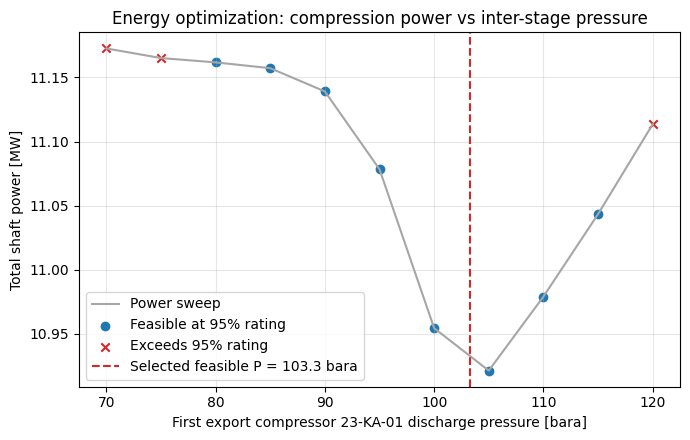

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep_p, sweep_power / 1e3, "-", color="0.65", label="Power sweep")
mask = np.array(sweep_feasible)
ax.scatter(sweep_p[mask], sweep_power[mask] / 1e3, color="tab:blue", label="Feasible at 95% rating")
ax.scatter(sweep_p[~mask], sweep_power[~mask] / 1e3, marker="x", color="tab:red", label="Exceeds 95% rating")
ax.axvline(
    opt_interstage, color="tab:red", ls="--", label=f"Selected feasible P = {opt_interstage:.1f} bara"
)
ax.set_xlabel("First export compressor 23-KA-01 discharge pressure [bara]")
ax.set_ylabel("Total shaft power [MW]")
ax.set_title("Energy optimization: compression power vs inter-stage pressure")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


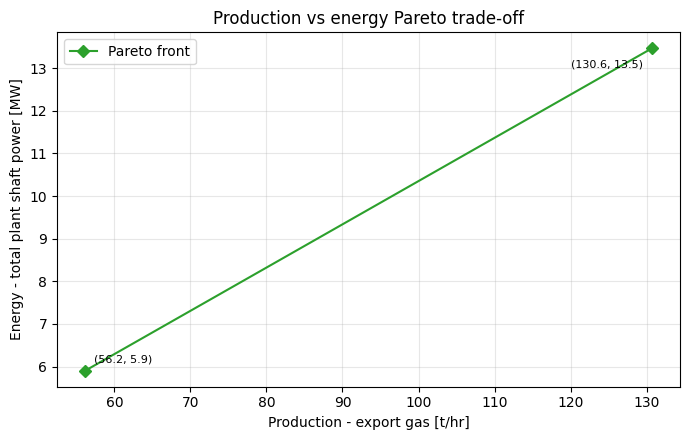

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
if pareto_prod:
    order = np.argsort(pareto_prod)
    pp = np.array(pareto_prod)[order] / 1e3
    pe = np.array(pareto_energy)[order] / 1e3
    ax.plot(pp, pe, "D-", color="tab:green", label="Pareto front")
    for point_index, (x, y) in enumerate(zip(pp, pe)):
        ax.annotate(
            f"({x:.1f}, {y:.1f})",
            (x, y),
            textcoords="offset points",
            xytext=(-6, -14) if point_index == len(pp) - 1 else (6, 6),
            ha="right" if point_index == len(pp) - 1 else "left",
            fontsize=8,
        )
ax.set_xlabel("Production - export gas [t/hr]")
ax.set_ylabel("Energy - total plant shaft power [MW]")
ax.set_title("Production vs energy Pareto trade-off")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


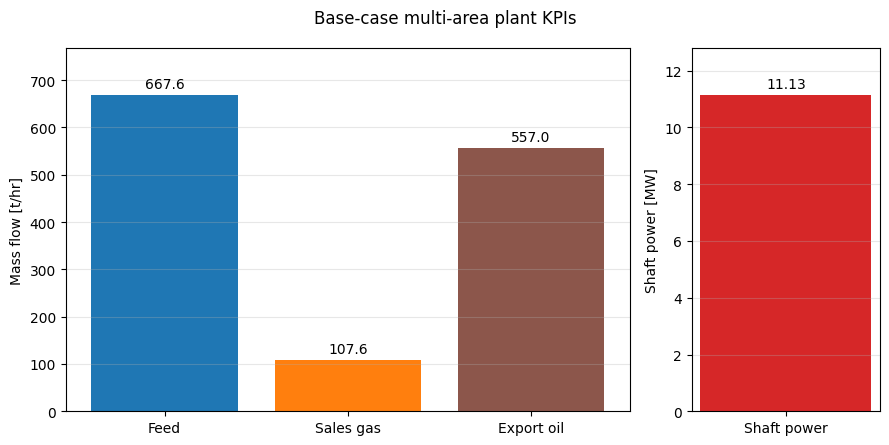

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), gridspec_kw={"width_ratios": [3, 1]})
flows = [base_feed_kgph / 1e3, base_sales_gas / 1e3, base_export_oil / 1e3]
bars = axes[0].bar(
    ["Feed", "Sales gas", "Export oil"], flows, color=["tab:blue", "tab:orange", "tab:brown"]
)
axes[0].bar_label(bars, fmt="%.1f", padding=3)
axes[0].set_ylabel("Mass flow [t/hr]")
axes[0].set_ylim(0, max(flows) * 1.15)
axes[0].grid(True, axis="y", alpha=0.3)
power_bars = axes[1].bar(["Shaft power"], [base_power / 1e3], color="tab:red")
axes[1].bar_label(power_bars, fmt="%.2f", padding=3)
axes[1].set_ylabel("Shaft power [MW]")
axes[1].set_ylim(0, base_power / 1e3 * 1.15)
axes[1].grid(True, axis="y", alpha=0.3)
fig.suptitle("Base-case multi-area plant KPIs")
fig.tight_layout()
plt.show()


## 8. Interpretation and limits

The notebook applies `ProductionOptimizer`, `ProcessModelThroughputOptimizer`
and `optimizePareto` to the complete two-area plant. Capacity results are relative
to the explicitly supplied compressor power ratings and other enabled constraints.
The energy study preserves interstage pressure losses and holds well feed fixed.

These are bounded steady-state searches with finite sampling and convergence
tolerances. The printed results and checks establish the evaluated cases; they
do not certify unmodeled equipment limits or a global optimum over all plant
operating variables. Economic or emissions optimization additionally requires
utility prices, efficiencies and an explicit emissions basis.


In [15]:
print("=== Optimization summary ===")
print(f"Base feed rate            : {base_feed_kgph:10.1f} kg/hr")
print(f"Throughput-opt feed rate  : {prod_opt_feed:10.1f} kg/hr")
print(f"Base total power          : {base_power:10.1f} kW")
print(f"Energy-opt total power    : {opt_power:10.1f} kW")
print(f"Energy-opt interstage P   : {opt_interstage:10.1f} bara")
if best is not None:
    print(f"Plant max feed multiplier : {best.getThroughputMultiplier():10.3f}")
print(f"Pareto front points       : {pareto_result.getParetoFrontSize():10d}")


=== Optimization summary ===
Base feed rate            :   667592.2 kg/hr
Throughput-opt feed rate  :   820495.6 kg/hr
Base total power          :    11129.6 kW
Energy-opt total power    :    10904.8 kW
Energy-opt interstage P   :      103.3 bara
Plant max feed multiplier :      1.288
Pareto front points       :          2
